DIAGNÓSTICO RADIAL - TRAYECTORIA 3
Duración = 4.005 s
r inicial = 2.563 cm
r final = 1.884 cm

Mediana u_r = -0.1846 cm/s
Puntos con u_r < 0 = 68.5 %
Puntos con u_r > 0 = 31.5 %

Pendiente de ln(r) = -0.083233 1/s
alpha inferido = 0.083233 1/s
R² del ajuste exponencial = 0.83306

INTERPRETACIÓN
El ajuste global da alpha > 0:
el radio disminuye globalmente, compatible en signo con Burgers.
La tendencia exponencial es aproximada, pero hay desviaciones apreciables.


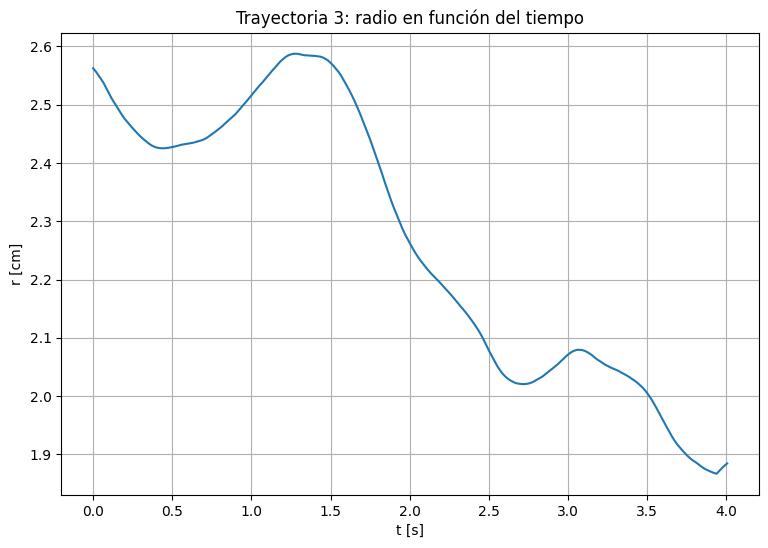

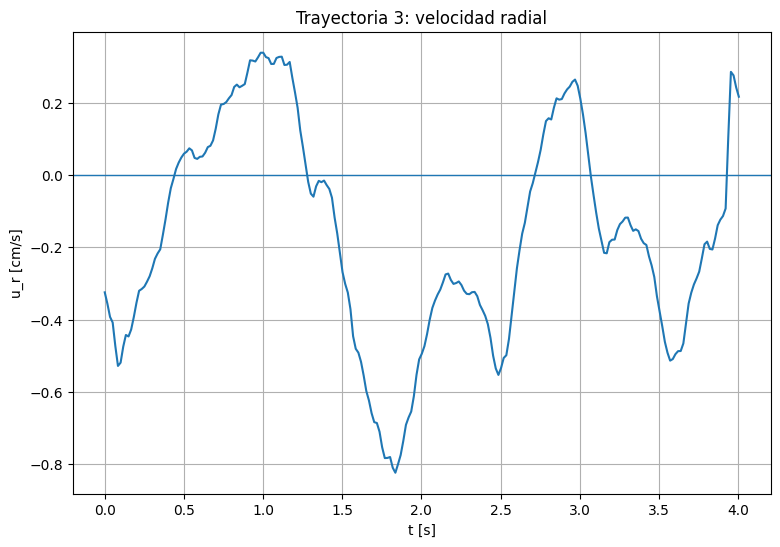

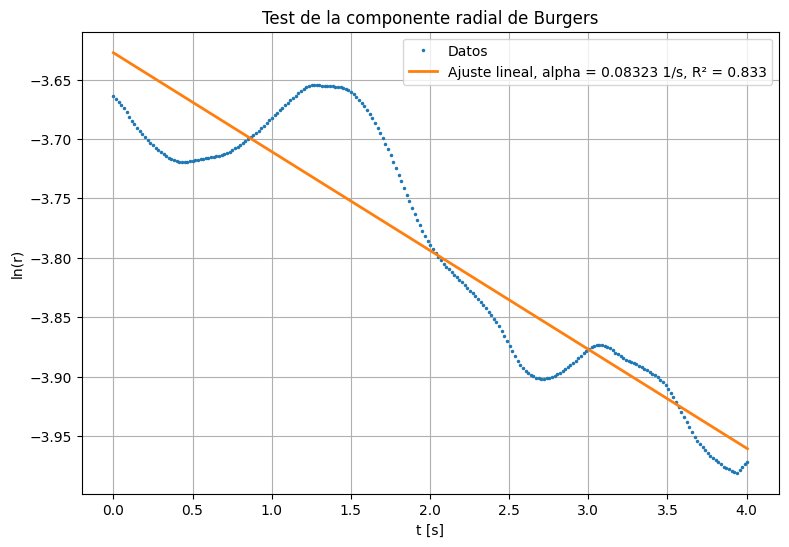

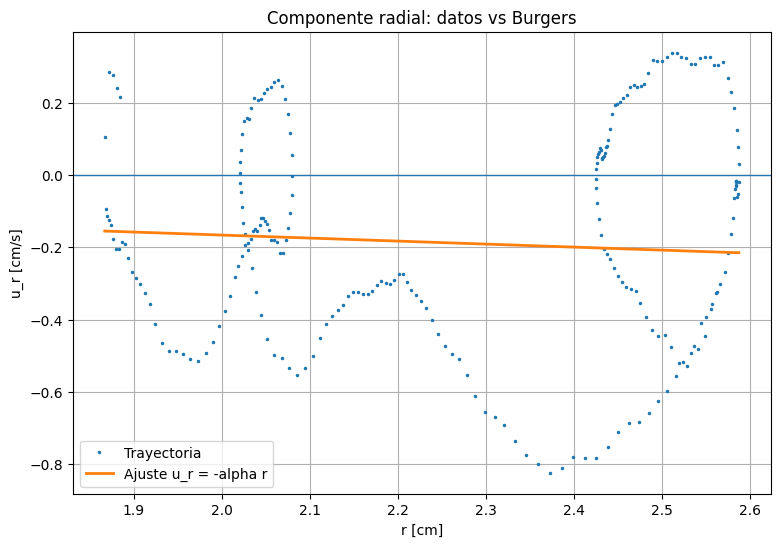

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# ARCHIVO
# ============================================================

ARCHIVO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3_PINN.csv"
)


df = pd.read_csv(
    ARCHIVO
)


# ============================================================
# CENTRO DEL VÓRTICE
# ============================================================

# IMPORTANTE:
#
# Los CSV ya están expresados respecto del origen que usamos
# durante el tracking.
#
# Si ese origen coincide con el centro real del vórtice:
XC_M = 0.0
YC_M = 0.0


# Si más adelante obtenés con PIV que el verdadero centro
# está desplazado, ponés aquí ese desplazamiento EN METROS.
#
# Por ejemplo:
#
# XC_M = 0.0012
# YC_M = -0.0008


# ============================================================
# DATOS
# ============================================================

t = df["t_s"].to_numpy()

x = df["x_m"].to_numpy()
y = df["y_m"].to_numpy()


# Coordenadas respecto del centro del vórtice

xr = (
    x - XC_M
)

yr = (
    y - YC_M
)


# ============================================================
# SUAVIZADO LEVE
# ============================================================

# El suavizado se usa SOLAMENTE para estimar derivadas.
#
# No modifica los datos empleados por la PINN.

VENTANA = 9


xr_s = (
    pd.Series(xr)
    .rolling(
        VENTANA,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)


yr_s = (
    pd.Series(yr)
    .rolling(
        VENTANA,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)


# ============================================================
# RADIO
# ============================================================

r = np.sqrt(
    xr_s**2
    + yr_s**2
)


# ============================================================
# VELOCIDAD RADIAL
# ============================================================

ur = np.gradient(
    r,
    t
)


# ============================================================
# ÁNGULO Y VELOCIDAD TANGENCIAL
# ============================================================

theta = np.unwrap(
    np.arctan2(
        yr_s,
        xr_s
    )
)


omega = np.gradient(
    theta,
    t
)


utheta = (
    r * omega
)


# ============================================================
# AJUSTE RADIAL DE BURGERS
# ============================================================

# Burgers:
#
# r(t) = r0 exp(-alpha t)
#
# ln(r) = ln(r0) - alpha t


mascara = (
    r > 1e-6
)


t_fit = t[
    mascara
]

ln_r = np.log(
    r[mascara]
)


pendiente, ordenada = np.polyfit(
    t_fit,
    ln_r,
    1
)


ln_r_fit = (
    pendiente * t_fit
    + ordenada
)


# alpha = -pendiente

alpha_fit = (
    -pendiente
)


# R^2

ss_res = np.sum(
    (
        ln_r
        - ln_r_fit
    )**2
)


ss_tot = np.sum(
    (
        ln_r
        - np.mean(ln_r)
    )**2
)


R2 = (
    1
    - ss_res / ss_tot
)


# ============================================================
# RESULTADOS NUMÉRICOS
# ============================================================

fraccion_entrante = np.mean(
    ur < 0
)


fraccion_saliente = np.mean(
    ur > 0
)


print("=" * 60)
print("DIAGNÓSTICO RADIAL - TRAYECTORIA 3")
print("=" * 60)

print(
    f"Duración = "
    f"{t[-1] - t[0]:.3f} s"
)

print(
    f"r inicial = "
    f"{100*r[0]:.3f} cm"
)

print(
    f"r final = "
    f"{100*r[-1]:.3f} cm"
)

print()

print(
    f"Mediana u_r = "
    f"{100*np.median(ur):.4f} cm/s"
)

print(
    f"Puntos con u_r < 0 = "
    f"{100*fraccion_entrante:.1f} %"
)

print(
    f"Puntos con u_r > 0 = "
    f"{100*fraccion_saliente:.1f} %"
)

print()

print(
    f"Pendiente de ln(r) = "
    f"{pendiente:.6f} 1/s"
)

print(
    f"alpha inferido = "
    f"{alpha_fit:.6f} 1/s"
)

print(
    f"R² del ajuste exponencial = "
    f"{R2:.5f}"
)


# ============================================================
# INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print()
print("=" * 60)
print("INTERPRETACIÓN")
print("=" * 60)


if alpha_fit > 0:

    print(
        "El ajuste global da alpha > 0:"
    )

    print(
        "el radio disminuye globalmente,"
        " compatible en signo con Burgers."
    )

else:

    print(
        "El ajuste global da alpha < 0:"
    )

    print(
        "el radio aumenta globalmente."
    )

    print(
        "Esto NO es compatible con el "
        "Burgers estándar con alpha > 0."
    )


if R2 > 0.95:

    print(
        "Además, r(t) es aproximadamente "
        "exponencial."
    )

elif R2 > 0.8:

    print(
        "La tendencia exponencial es aproximada, "
        "pero hay desviaciones apreciables."
    )

else:

    print(
        "r(t) NO sigue bien una única exponencial."
    )

    print(
        "Un único alpha constante probablemente "
        "no describe toda la trayectoria."
    )


# ============================================================
# GRÁFICO 1: r(t)
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    100 * r
)


plt.xlabel(
    "t [s]"
)

plt.ylabel(
    "r [cm]"
)

plt.title(
    "Trayectoria 3: radio en función del tiempo"
)

plt.grid()

plt.show()


# ============================================================
# GRÁFICO 2: VELOCIDAD RADIAL
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    100 * ur
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel(
    "t [s]"
)

plt.ylabel(
    "u_r [cm/s]"
)

plt.title(
    "Trayectoria 3: velocidad radial"
)

plt.grid()

plt.show()


# ============================================================
# GRÁFICO 3: TEST DIRECTO DE BURGERS
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t_fit,
    ln_r,
    ".",
    markersize=3,
    label="Datos"
)


plt.plot(
    t_fit,
    ln_r_fit,
    linewidth=2,
    label=(
        f"Ajuste lineal, "
        f"alpha = {alpha_fit:.4g} 1/s, "
        f"R² = {R2:.3f}"
    )
)


plt.xlabel(
    "t [s]"
)

plt.ylabel(
    "ln(r)"
)

plt.title(
    "Test de la componente radial de Burgers"
)

plt.grid()

plt.legend()

plt.show()


# ============================================================
# GRÁFICO 4: u_r(r)
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    100 * r,
    100 * ur,
    ".",
    markersize=3,
    label="Trayectoria"
)


# Predicción radial usando el alpha obtenido

r_modelo = np.linspace(
    r.min(),
    r.max(),
    300
)


ur_modelo = (
    -alpha_fit
    * r_modelo
)


plt.plot(
    100 * r_modelo,
    100 * ur_modelo,
    linewidth=2,
    label="Ajuste u_r = -alpha r"
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel(
    "r [cm]"
)

plt.ylabel(
    "u_r [cm/s]"
)

plt.title(
    "Componente radial: datos vs Burgers"
)

plt.grid()

plt.legend()

plt.show()

Frecuencia de muestreo = 59.923 Hz
Duración = 41.370 s
Resolución espectral ≈ 0.0242 Hz
alpha radial aproximado = -0.00040 1/s

OSCILACIÓN RADIAL
Frecuencia dominante = 0.1208 Hz
Periodo dominante = 8.277 s
Amplitud espectral = 2.047 mm

ROTACIÓN DE LA PELOTA
Frecuencia media ≈ 0.3942 Hz
RPM aproximadas ≈ 23.65 rpm

Cociente f_oscilacion / f_particula = 0.306


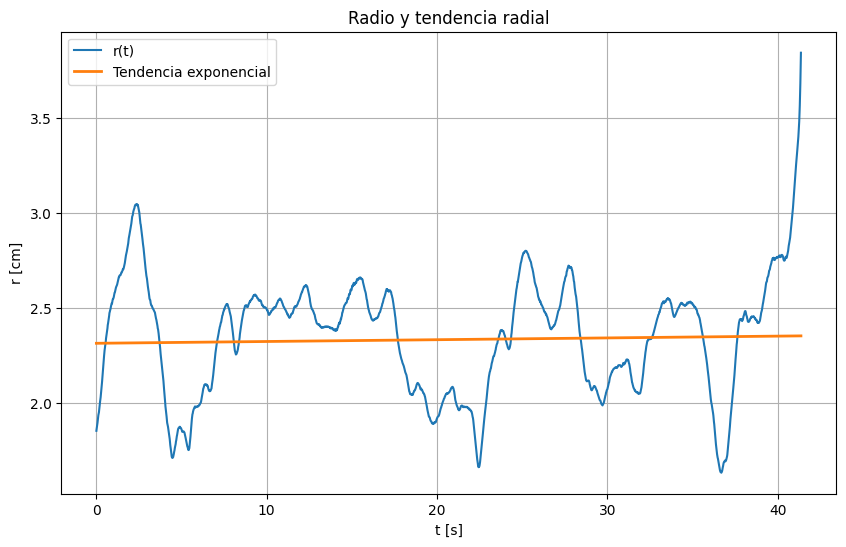

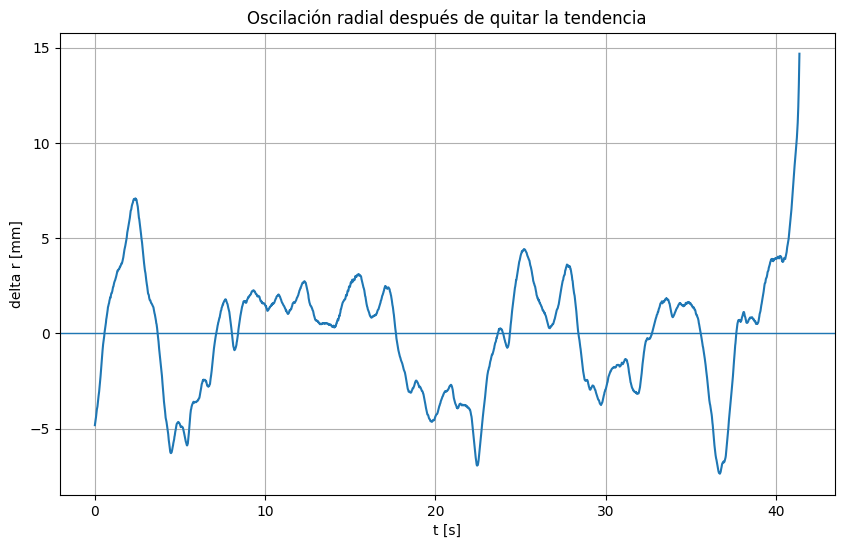

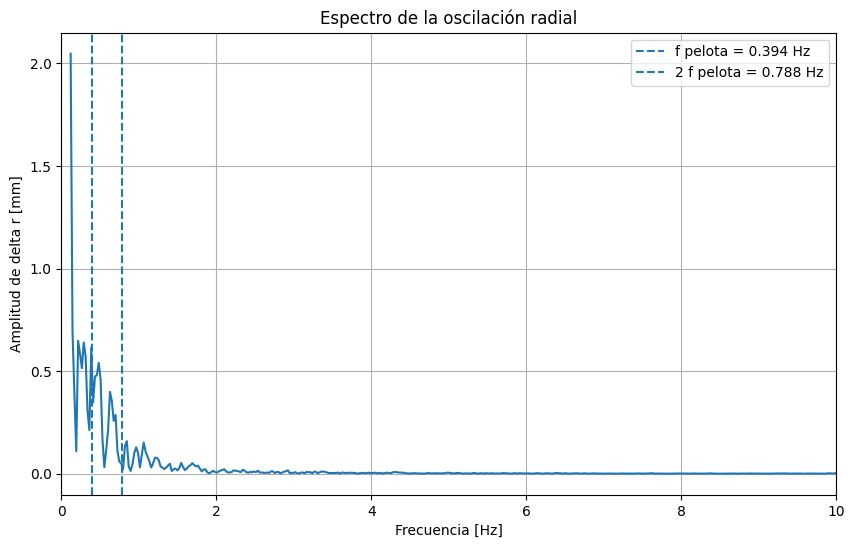

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# ARCHIVO
# ============================================================

ARCHIVO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3_COMPLETA.csv"
)

df = pd.read_csv(ARCHIVO)


# ============================================================
# CENTRO DEL VÓRTICE
# ============================================================

# Por ahora usamos el origen de tus coordenadas.
# Si después tenemos xc(t), yc(t), esto se puede mejorar mucho.

XC = 0.0
YC = 0.0


# ============================================================
# DATOS
# ============================================================

t = df["t_s"].to_numpy()
x = df["x_m"].to_numpy() - XC
y = df["y_m"].to_numpy() - YC


r = np.sqrt(
    x**2 + y**2
)


theta = np.unwrap(
    np.arctan2(
        y,
        x
    )
)


# ============================================================
# 1. TENDENCIA RADIAL
# ============================================================

# Ajustamos Burgers:
#
# r(t) = r0 exp(-alpha t)
#
# ln(r) = ln(r0) - alpha*t


coef = np.polyfit(
    t,
    np.log(r),
    1
)


pendiente = coef[0]
ordenada = coef[1]


alpha = -pendiente


r_tendencia = np.exp(
    ordenada
    + pendiente * t
)


# Residuo radial

delta_r = (
    r
    - r_tendencia
)


# Sacamos cualquier pequeño offset restante

delta_r = (
    delta_r
    - np.mean(delta_r)
)


# ============================================================
# 2. FRECUENCIA DE MUESTREO
# ============================================================

dt = np.median(
    np.diff(t)
)


fs = 1 / dt


print(
    f"Frecuencia de muestreo = "
    f"{fs:.3f} Hz"
)

print(
    f"Duración = "
    f"{t[-1] - t[0]:.3f} s"
)

print(
    f"Resolución espectral ≈ "
    f"{1/(t[-1]-t[0]):.4f} Hz"
)

print(
    f"alpha radial aproximado = "
    f"{alpha:.5f} 1/s"
)


# ============================================================
# 3. VENTANA DE HANN
# ============================================================

# Reduce problemas producidos por los extremos
# de la señal.

ventana = np.hanning(
    len(delta_r)
)


senal = (
    delta_r
    * ventana
)


# ============================================================
# 4. FFT
# ============================================================

fft = np.fft.rfft(
    senal
)


frecuencias = np.fft.rfftfreq(
    len(senal),
    d=dt
)


amplitud = np.abs(
    fft
)


# Normalización aproximada de amplitud

amplitud = (
    2
    * amplitud
    / np.sum(ventana)
)


# Pasamos amplitud a mm

amplitud_mm = (
    1000
    * amplitud
)


# ============================================================
# 5. IGNORAR FRECUENCIAS MUY BAJAS
# ============================================================

# Estas pueden ser todavía parte de la deriva lenta.

F_MIN = 0.10


mascara = (
    frecuencias >= F_MIN
)


freq_analisis = (
    frecuencias[mascara]
)


amp_analisis = (
    amplitud_mm[mascara]
)


indice_max = np.argmax(
    amp_analisis
)


frecuencia_dominante = (
    freq_analisis[indice_max]
)


amplitud_dominante = (
    amp_analisis[indice_max]
)


print()
print("=" * 60)
print("OSCILACIÓN RADIAL")
print("=" * 60)

print(
    f"Frecuencia dominante = "
    f"{frecuencia_dominante:.4f} Hz"
)

print(
    f"Periodo dominante = "
    f"{1/frecuencia_dominante:.3f} s"
)

print(
    f"Amplitud espectral = "
    f"{amplitud_dominante:.3f} mm"
)


# ============================================================
# 6. FRECUENCIA DE GIRO DE LA PELOTA
# ============================================================

omega_particula = np.gradient(
    theta,
    t
)


f_particula = (
    np.median(
        np.abs(
            omega_particula
        )
    )
    / (2 * np.pi)
)


rpm_particula = (
    60
    * f_particula
)


print()
print("=" * 60)
print("ROTACIÓN DE LA PELOTA")
print("=" * 60)

print(
    f"Frecuencia media ≈ "
    f"{f_particula:.4f} Hz"
)

print(
    f"RPM aproximadas ≈ "
    f"{rpm_particula:.2f} rpm"
)


print()
print(
    "Cociente f_oscilacion / f_particula = "
    f"{frecuencia_dominante/f_particula:.3f}"
)


# ============================================================
# 7. GRÁFICO: RADIO + TENDENCIA
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    t,
    100 * r,
    label="r(t)"
)


plt.plot(
    t,
    100 * r_tendencia,
    linewidth=2,
    label="Tendencia exponencial"
)


plt.xlabel(
    "t [s]"
)

plt.ylabel(
    "r [cm]"
)

plt.title(
    "Radio y tendencia radial"
)

plt.grid()

plt.legend()

plt.show()


# ============================================================
# 8. GRÁFICO DEL RESIDUO
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    t,
    1000 * delta_r
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel(
    "t [s]"
)

plt.ylabel(
    "delta r [mm]"
)

plt.title(
    "Oscilación radial después de quitar la tendencia"
)

plt.grid()

plt.show()


# ============================================================
# 9. ESPECTRO
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    freq_analisis,
    amp_analisis
)


# Frecuencia orbital de la pelota

plt.axvline(
    f_particula,
    linestyle="--",
    label=(
        f"f pelota = "
        f"{f_particula:.3f} Hz"
    )
)


# Dos veces la frecuencia orbital

plt.axvline(
    2 * f_particula,
    linestyle="--",
    label=(
        f"2 f pelota = "
        f"{2*f_particula:.3f} Hz"
    )
)


plt.xlim(
    0,
    min(
        10,
        fs / 2
    )
)


plt.xlabel(
    "Frecuencia [Hz]"
)

plt.ylabel(
    "Amplitud de delta r [mm]"
)

plt.title(
    "Espectro de la oscilación radial"
)

plt.grid()

plt.legend()

plt.show()